In [1]:
import pandas as pd
# My teammate Matias preprocessed the dataset, removed invalid rows of data. 
df = pd.read_csv('crypto_cleaned.csv')
print(f' Row and Column # in the dataset: {df.shape}')
print(f'The column names: {df.columns}')


 Row and Column # in the dataset: (824600, 14)
The column names: Index(['slug', 'symbol', 'name', 'date', 'ranknow', 'open', 'high', 'low',
       'close', 'volume', 'market', 'close_ratio', 'spread',
       'volume_missing_flag'],
      dtype='object')


In [2]:
import numpy as np
import pickle
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam


# Convert date column to datetime and sort by date
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
# Create more features based on existing ones. Suggested by my teammate Soumya.
df['spread'] = df['high'] - df['low']
df['return'] = (df['close'] - df['open']) / df['open']

# df['volume_lag1'] = df['volume'].shift(1)
# df.drop(['close_lag1','target'],axis=1,inplace=True)
df = df.dropna()
df.head()

2025-07-27 15:26:58.874599: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


,slug,symbol,name,date,ranknow,open,high,low,close,volume,market,close_ratio,spread,volume_missing_flag,return
0,bitcoin,BTC,Bitcoin,2013-04-28,1,135.300000,135.980000,132.100000,134.210000,0.0,1.488567e+09,0.5438,3.880000,True,-0.008056
307068,novacoin,NVC,Novacoin,2013-04-28,700,4.220000,4.250000,4.040000,4.250000,0.0,1.162268e+06,1.0000,0.210000,True,0.007109
185144,namecoin,NMC,Namecoin,2013-04-28,371,1.100000,1.120000,1.080000,1.110000,0.0,5.995983e+06,0.7500,0.040000,True,0.009091
386338,terracoin,TRC,Terracoin,2013-04-28,895,0.650793,0.654064,0.634409,0.646892,0.0,1.503099e+06,0.6351,0.019655,True,-0.005994
7776,litecoin,LTC,Litecoin,2013-04-28,7,4.300000,4.400000,4.180000,4.350000,0.0,7.463694e+07,0.7727,0.220000,True,0.011628


In [3]:
# Target: the close price on the next day
df.sort_values(by=['symbol','date'],inplace=True)
df['target'] = df.groupby('symbol')['close'].shift(-1)
df[df['symbol']=='BTC'].head()

            

,slug,symbol,name,date,ranknow,open,high,low,close,volume,market,close_ratio,spread,volume_missing_flag,return,target
0,bitcoin,BTC,Bitcoin,2013-04-28,1,135.30,135.98,132.10,134.21,0.0,1.488567e+09,0.5438,3.88,True,-0.008056,144.54
1,bitcoin,BTC,Bitcoin,2013-04-29,1,134.44,147.49,134.00,144.54,0.0,1.603769e+09,0.7813,13.49,True,0.075126,139.00
2,bitcoin,BTC,Bitcoin,2013-04-30,1,144.00,146.93,134.05,139.00,0.0,1.542813e+09,0.3843,12.88,True,-0.034722,116.99
3,bitcoin,BTC,Bitcoin,2013-05-01,1,139.00,139.89,107.72,116.99,0.0,1.298955e+09,0.2882,32.17,True,-0.158345,105.21
4,bitcoin,BTC,Bitcoin,2013-05-02,1,116.38,125.60,92.28,105.21,0.0,1.168517e+09,0.3881,33.32,True,-0.095979,97.75


In [5]:
df['ma_3'] = df.groupby('symbol')['close'].rolling(window=3, min_periods=1).mean().reset_index(level=0, drop=True)
df['ma_7'] = df.groupby('symbol')['close'].rolling(window=7, min_periods=1).mean().reset_index(level=0, drop=True)
df['ma_14'] = df.groupby('symbol')['close'].rolling(window=14, min_periods=1).mean().reset_index(level=0, drop=True)
df['volatility_7'] = df.groupby('symbol')['close'].rolling(window=7, min_periods=1).std().reset_index(level=0, drop=True)

In [6]:
df[['date','symbol','close','target','ma_3','ma_7','ma_14','volatility_7']].head(15)

,date,symbol,close,target,ma_3,ma_7,ma_14,volatility_7
753254,2015-12-10,$$$,0.000050,0.000027,0.000050,0.000050,0.000050,NaN
753255,2015-12-11,$$$,0.000027,0.000043,0.000039,0.000039,0.000039,1.626346e-05
753256,2015-12-12,$$$,0.000043,0.000022,0.000040,0.000040,0.000040,1.178983e-05
753257,2015-12-13,$$$,0.000022,0.000022,0.000031,0.000036,0.000036,1.317826e-05
753258,2015-12-14,$$$,0.000022,0.000023,0.000029,0.000033,0.000033,1.291124e-05
753259,2015-12-15,$$$,0.000023,0.000023,0.000022,0.000031,0.000031,1.222157e-05
753260,2015-12-16,$$$,0.000023,0.000023,0.000023,0.000030,0.000030,1.157584e-05
753261,2015-12-17,$$$,0.000023,0.000023,0.000023,0.000026,0.000029,7.625146e-06
753262,2015-12-18,$$$,0.000023,0.000023,0.000023,0.000026,0.000028,7.699722e-06
753263,2015-12-19,$$$,0.000023,0.000022,0.000023,0.000023,0.000028,4.879500e-07


In [7]:
# Encode symbols for the coins
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
symbol_encoder = LabelEncoder()

# Encode the 'Symbol' column
df['symbol_encoded'] = symbol_encoder.fit_transform(df['symbol'])

# Print the DataFrame with encoded column
print(df[['symbol','symbol_encoded']].head)

# the mapping of symbols to numeric values
print("Symbol to Numeric Mapping:", dict(zip(symbol_encoder.classes_, symbol_encoder.transform(symbol_encoder.classes_))))


<bound method NDFrame.head of        symbol  symbol_encoded
753254    $$$               0
753255    $$$               0
753256    $$$               0
753257    $$$               0
753258    $$$               0
...       ...             ...
696476    ZZC            1715
696477    ZZC            1715
696478    ZZC            1715
696479    ZZC            1715
696480    ZZC            1715

[824600 rows x 2 columns]>
Symbol to Numeric Mapping: {'$$$': np.int64(0), '$PAC': np.int64(1), '0XBTC': np.int64(2), '1337': np.int64(3), '1ST': np.int64(4), '1WO': np.int64(5), '2GIVE': np.int64(6), '2GO': np.int64(7), '300': np.int64(8), '42': np.int64(9), '611': np.int64(10), '808': np.int64(11), '8BIT': np.int64(12), 'AAA': np.int64(13), 'AAC': np.int64(14), 'ABL': np.int64(15), 'ABS': np.int64(16), 'ABT': np.int64(17), 'ABX': np.int64(18), 'ABY': np.int64(19), 'ABYSS': np.int64(20), 'AC': np.int64(21), 'AC3': np.int64(22), 'ACAT': np.int64(23), 'ACC': np.int64(24), 'ACE': np.int64(25), 'ACED': np

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 824600 entries, 753254 to 696480
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   slug                 824600 non-null  object        
 1   symbol               824600 non-null  object        
 2   name                 824600 non-null  object        
 3   date                 824600 non-null  datetime64[ns]
 4   ranknow              824600 non-null  int64         
 5   open                 824600 non-null  float64       
 6   high                 824600 non-null  float64       
 7   low                  824600 non-null  float64       
 8   close                824600 non-null  float64       
 9   volume               824600 non-null  float64       
 10  market               824600 non-null  float64       
 11  close_ratio          824600 non-null  float64       
 12  spread               824600 non-null  float64       
 13  volume_missing

In [9]:
symbol_counts = df.groupby('symbol').size()

In [10]:
# Keep only symbols with row count >= 50 to ensure enough training data for the model.
# symbols_2_predict = symbol_counts[symbol_counts >= 50].index
# len(symbols_2_predict)
symbols_2_predict = ['BTC'] #BCH BTC 0XBTC

In [11]:
# Create sequences for GRU
def create_sequences(X, y, time_steps=10):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

In [12]:
# 10 coins with the larget market value on the specified date. 
# 2018-11-30 is the larget date in the dataset but there are only 2 rows so the previous day is picked.
# More details aobut these coins will be collected in the model training.
symbols_largest_market = df[df['date']=='2018-11-29 00:00:00'].nlargest(10,'market')['symbol']
symbols_largest_market

2041      BTC
3985      XRP
5196      ETH
7260      BCH
6774      XLM
7775      EOS
9817      LTC
11186    USDT
11190     BSV
11614     ADA
Name: symbol, dtype: object

In [19]:
# Normalize/scale features
scaler = MinMaxScaler()

time_steps = 10  # Number of time steps in each sequence

evaluation_results = []
prediction_results = {}
actual_results = {}

count = 0

for symbol in symbols_2_predict:
    print(symbol)
    count += 1
    print(count)
    # Extract features and target
    X = df[(df['symbol']==symbol)& (df['close']>2500)]
    X = X.drop(columns=['date', 'slug','volume_missing_flag','symbol','name','target'])
    
    # fill the null values with the next value
    X['volatility_7'].bfill(inplace=True)

    y = df[(df['symbol']==symbol)& (df['close']>2500)]['target']
    # fill the null values with the previous target value
    y.ffill(inplace=True)
    y = y.values
    
    # normalize features
    X_scaled = scaler.fit_transform(X)
    X_seq, y_seq = create_sequences(X_scaled, y, time_steps)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, shuffle=False)

    actual_results[symbol] = y_test.flatten()

    model = Sequential([
        GRU(units=64, return_sequences=True, input_shape=(time_steps, X_train.shape[2])),
        # Dropout(0.2),
        GRU(units=32),
        # Dropout(0.2),
        Dense(units=16, activation='relu'),
        Dense(units=1)  # Output layer for regression ; ,activation='linear'
    ])

    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.01), loss='mse', metrics=['mae'])

    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=16,
        validation_split=0.2,
        verbose=1
    )

    test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)

    predictions = model.predict(X_test)

    evaluation_results.append([symbol,test_loss,test_mae])
    prediction_results[symbol] = predictions.flatten() # For individual coin testing

    '''
    # For coin batch testing
    if symbol in symbols_largest_market.values:
        prediction_results[symbol] = predictions.flatten()

        pickle_file_name = 'gru_model_'+symbol+'.pkl'
        with open(pickle_file_name, 'wb') as file:
            pickle.dump(model, file)
    '''
    

BTC
1
Epoch 1/50


/var/folders/xd/827g3ndd0kg_81hlxd5mbp2m0000gn/T/ipykernel_43133/2618409316.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['volatility_7'].bfill(inplace=True)
/var/folders/xd/827g3ndd0kg_81hlxd5mbp2m0000gn/T/ipykernel_43133/2618409316.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y.ffill(inplace=True)
/opt/miniconda3/envs/dsi_xz

21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 73000248.0000 - mae: 7628.5581 - val_loss: 48221624.0000 - val_mae: 6914.8394
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 72320968.0000 - mae: 7600.8340 - val_loss: 47479928.0000 - val_mae: 6860.9990
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 77519824.0000 - mae: 7891.7344 - val_loss: 46260628.0000 - val_mae: 6771.5586
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 73145720.0000 - mae: 7590.7500 - val_loss: 44532200.0000 - val_mae: 6642.7090
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 74499304.0000 - mae: 7639.2681 - val_loss: 42264292.0000 - val_mae: 6469.7500
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 63552832.0000 - mae: 7026.2451 - val_loss: 39556840.0000 - val_mae: 6257.0132
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 62730200.0000 - mae: 6968.7725 - val_loss: 36405100.0000 - val_mae: 5999.8726
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step -

In [14]:
evaluation_results

[['BTC', 2038764.25, 1194.662353515625]]

In [15]:

columns = ['symbol','test_loss','test_mae']
df_test_results = pd.DataFrame(evaluation_results,columns=columns)
df_test_results.head()

,symbol,test_loss,test_mae
0,BTC,2038764.25,1194.662354


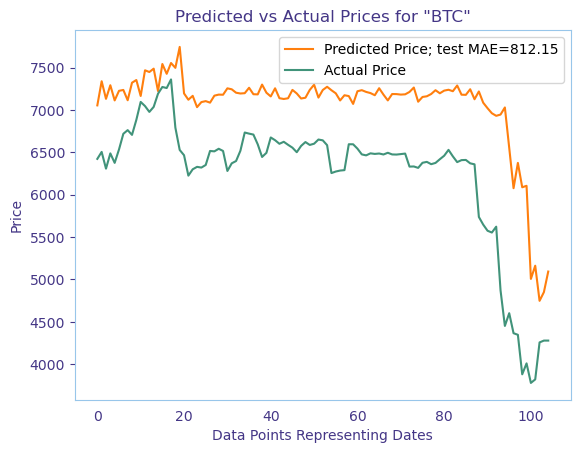

In [20]:
import matplotlib.pyplot as plt

def plot_template():
    fig, ax = plt.subplots()
    ax.spines['bottom'].set_color('#98c6ea')  # x-axis color
    ax.spines['top'].set_color('#98c6ea')
    ax.spines['left'].set_color('#98c6ea')    # y-axis color
    ax.spines['right'].set_color('#98c6ea')
    ax.grid(True, color='#98c6ea', linestyle='--', linewidth=0.5) 
    ax.tick_params(axis='x', colors='#443686')  # x-axis tick labels
    ax.tick_params(axis='y', colors="#443686")   # y-axis tick labels
    return ax

ax = plot_template()


ax.plot(prediction_results[symbols_2_predict[0]], color='#ff7f0e', label=f'Predicted Price; test MAE={evaluation_results[0][2]:.2f}') #marker='o', linestyle='-', 
# plt.plot(row_counts_per_day.keys()[:100], row_counts_per_day.values[:100], color='#98c6ea', label='Row Counts Per Day') #marker='o', linestyle='-', 
ax.plot(actual_results[symbols_2_predict[0]], color="#41937a", label='Actual Price')

# Customize axis title colors
ax.set_xlabel('Data Points Representing Dates', color='#443686')  # x-axis title color
ax.set_ylabel('Price', color='#443686') # y-axis title color
ax.set_title(f'Predicted vs Actual Prices for "{symbols_2_predict[0]}"', color='#443686')  # Plot title color
ax.grid(False) 
ax.tick_params(axis='x', colors='#443686', which='both', bottom=False)

plt.legend()

plt.show()

The following is the result when using all the data for BTC to train and test the model. I think this may be related to Tain-test-split and the actual price pattern. GRU model is for time series data, and the time-based sequence is critical so when doing train-test-data split, the shuffle setting is set to false. The training data are from the first 1600 days when the price was about several hundred$ most of time. So when making predictions, the model predicted the price to be around $400. Then I use the data where closing price is over 2500 to train and test the model, as shown in the above code. I also changed the learning rate from 0.005 to 0.01. Then I got a better result as shown in the above graph. 

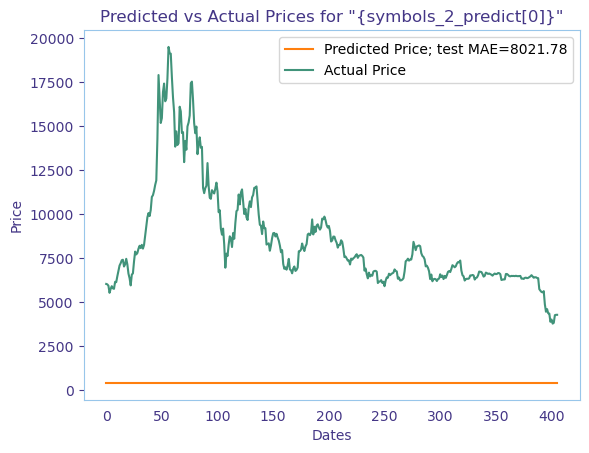


The following is the result for the coin named "Bitcoin Cash"

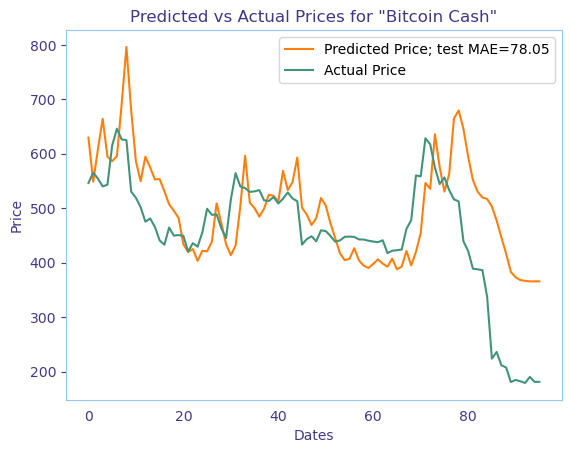

The following is the result for the coin whose symbol is  "OXBTC"

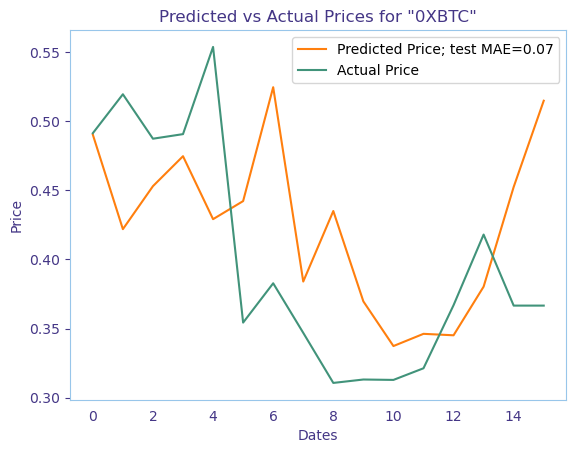

In [118]:
df[df['symbol']=='BTC'].shape

(2040, 21)